# Regression Fundamentals

Many real-world problems require predicting a numerical value.

Examples include:

- House Price
- Salary
- Temperature
- Sales Revenue

These are called **Regression Problems**.

In this notebook, we'll understand what regression is, how Linear Regression works conceptually, why models make errors, and how to recognize underfitting and overfitting.

# Learning Objectives

By the end of this notebook, you will be able to:

- Explain what regression is.
- Distinguish regression from classification.
- Understand the intuition behind Linear Regression.
- Explain the concept of a best-fit line.
- Understand residuals (prediction errors).
- Understand the purpose of a cost function.
- Differentiate underfitting and overfitting.
- Explain bias and variance at a high level.
- Understand why regularization is used.

# What is Regression?

Regression is a supervised Machine Learning technique used to predict **continuous numerical values**.

The model learns the relationship between input features and a numerical target.

Examples:

- Predicting house prices
- Predicting salaries
- Predicting temperatures
- Predicting electricity consumption

In [13]:
import pandas as pd

df = pd.DataFrame(
    {
        "Experience (Years)": [1, 2, 3, 5, 7],
        "Salary": [300000, 400000, 500000, 700000, 900000],
    }
)

df

,Experience (Years),Salary
0,1,300000
1,2,400000
2,3,500000
3,5,700000
4,7,900000


Suppose we want to predict a person's salary.

Feature:

- Years of Experience

Target:

- Salary

The model learns the relationship between experience and salary using historical data.

# Regression vs Classification

Although both are supervised learning techniques, they solve different types of problems.

Regression predicts numerical values.

Classification predicts categories.

In [14]:
comparison = pd.DataFrame(
    {
        "Regression": [
            "₹45,00,000",
            "32°C",
            "₹8,50,000",
        ],
        "Classification": [
            "Spam",
            "Dog",
            "Approved",
        ],
    }
)

comparison

,Regression,Classification
0,"₹45,00,000",Spam
1,32°C,Dog
2,"₹8,50,000",Approved


Examples:

Regression

- Predict House Price
- Predict Salary
- Predict Temperature

Classification

- Spam or Not Spam
- Fraud or Not Fraud
- Disease or No Disease

The key difference is the type of prediction.

Regression outputs numbers.

Classification outputs categories.

# What is Linear Regression?

Linear Regression is one of the simplest Machine Learning algorithms.

It assumes that the relationship between the input features and the target can be approximated by a straight line.

During training, the model tries to find the line that best represents the data.

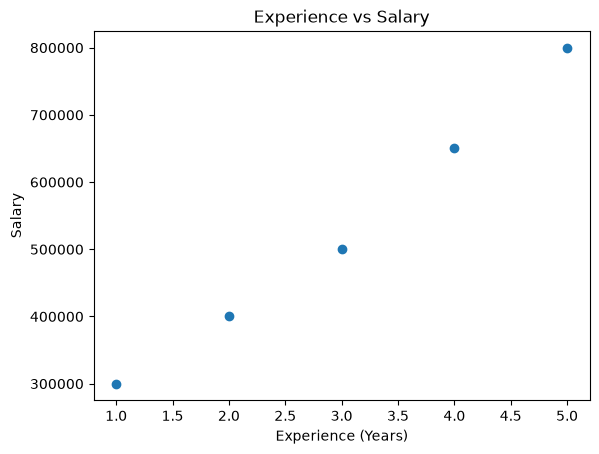

In [15]:
import matplotlib.pyplot as plt

experience = [1, 2, 3, 4, 5]
salary = [300000, 400000, 500000, 650000, 800000]

plt.scatter(experience, salary)

plt.title("Experience vs Salary")

plt.xlabel("Experience (Years)")

plt.ylabel("Salary")

plt.show()

Imagine drawing a straight line that passes as close as possible to all the points.

This line represents the relationship learned by Linear Regression.

The objective is not to pass through every point, but to minimize the overall prediction error.

# Interview Insight

### What is Regression?

A supervised learning technique used to predict continuous numerical values.

---

### Give three examples of regression problems.

- House Price Prediction
- Salary Prediction
- Temperature Prediction

---

### What is the difference between Regression and Classification?

Regression predicts numerical values, while classification predicts categories.

---

### What assumption does Linear Regression make?

It assumes a linear relationship between the input features and the target variable.

# The Best-Fit Line

Linear Regression tries to find the straight line that best represents the relationship between the input features and the target.

This line is called the **Best-Fit Line**.

The objective is not to pass through every data point.

Instead, it tries to minimize the overall prediction error across all observations.

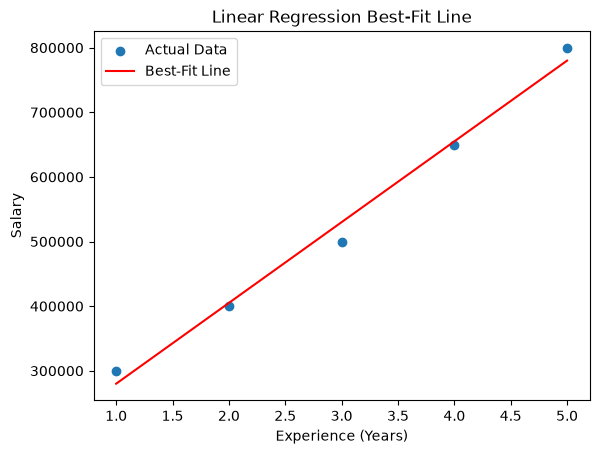

In [17]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(
    {
        "Experience": [1, 2, 3, 4, 5],
        "Salary": [300000, 400000, 500000, 650000, 800000],
    }
)

X = df[["Experience"]]

y = df["Salary"]

model = LinearRegression()

model.fit(X,y)

predicted_salary = model.predict(X)

plt.scatter(X, y, label="Actual Data")
plt.plot(X, predicted_salary, color="red", label="Best-Fit Line")

plt.title("Linear Regression Best-Fit Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

plt.legend()

plt.show()

Notice that the red line does not pass through every point.

This is expected.

The goal of Linear Regression is to find the line that minimizes the overall prediction error rather than fitting every observation perfectly.

# Residual (Prediction Error)

A residual is the difference between the actual value and the predicted value.

Residual = Actual Value − Predicted Value

Every prediction made by a model has an associated residual.

Smaller residuals indicate more accurate predictions.

In [19]:
results = pd.DataFrame(
    {
        "Actual": y,
        "Predicted": predicted_salary.round(0),
    }
)

results["Residual"] = results["Actual"] - results["Predicted"]

results

,Actual,Predicted,Residual
0,300000,280000.0,20000.0
1,400000,405000.0,-5000.0
2,500000,530000.0,-30000.0
3,650000,655000.0,-5000.0
4,800000,780000.0,20000.0


If the residual is:

- Close to 0 → Good prediction
- Large positive → Model predicted too low
- Large negative → Model predicted too high

A good regression model aims to keep residuals as small as possible.

# Connection to Our House Price Project

In the House Price Prediction project, every prediction had a residual.

For example:

Actual Price: ₹62,20,000

Predicted Price: ₹41,00,000

Residual = ₹21,20,000

Metrics such as MAE and RMSE summarize these residuals across all predictions to measure overall model performance.

# Why Don't Models Predict Perfectly?

Real-world data is noisy.

Many factors influence the target that may not be present in the dataset.

For example, house prices also depend on factors such as:

- Nearby schools
- Public transport
- Property age
- Interior quality
- Market conditions

If these features are unavailable, the model cannot learn their effect.

As a result, prediction errors are unavoidable.

# Interview Insight

### What is the Best-Fit Line?

The straight line learned by Linear Regression that minimizes the overall prediction error.

---

### What is a residual?

The difference between the actual value and the predicted value.

---

### Why doesn't Linear Regression pass through every point?

Because it minimizes the total prediction error across all observations rather than fitting every individual point exactly.

---

### Why do regression models make prediction errors?

Because real-world data contains noise and may not include every factor that influences the target variable.

# Cost Function

A model needs a way to measure how well it is performing.

This is the purpose of a **Cost Function**.

A cost function calculates the overall prediction error made by the model.

During training, the model tries to minimize this error.

Lower cost generally indicates better model performance.

# Underfitting

Underfitting occurs when a model is too simple to learn the underlying patterns in the data.

Characteristics:

- High training error
- High testing error

The model fails to capture the relationship between the features and the target variable.

# Overfitting

Overfitting occurs when a model learns the training data too closely, including noise and random variations.

Characteristics:

- Very low training error
- High testing error

Although the model performs well on the training data, it does not generalize well to new, unseen data.

# Bias and Variance

Bias and variance help explain why models underfit or overfit.

High Bias

- Model is too simple.
- Often leads to underfitting.

High Variance

- Model is too complex.
- Often leads to overfitting.

A good Machine Learning model maintains a balance between bias and variance.

# Regularization

Regularization is a technique used to reduce overfitting.

Instead of allowing the model to become unnecessarily complex, regularization discourages overly large model parameters.

Common regularization techniques include:

- Ridge Regression
- Lasso Regression
- ElasticNet

These algorithms will be covered in the next notebook.

# Connection to Our House Price Project

Our first Linear Regression model achieved:

- MAE ≈ 6.7 Million
- RMSE ≈ 18.1 Million
- R² ≈ 0.24

After improving the data cleaning process, removing unrealistic records, and training on the refined dataset, the model improved to:

- MAE ≈ 5.8 Million
- RMSE ≈ 17.1 Million
- R² ≈ 0.38

Later, using a Pipeline further improved the model to approximately:

- MAE ≈ 6.1 Million
- RMSE ≈ 15.4 Million
- R² ≈ 0.41

This shows that improving data quality and preprocessing can significantly improve model performance without changing the algorithm.

# Key Takeaways

- Regression predicts continuous numerical values.
- Linear Regression learns a best-fit line.
- Residuals measure prediction error.
- Cost functions help evaluate model performance.
- Underfitting occurs when a model is too simple.
- Overfitting occurs when a model is too complex.
- Bias and variance explain the trade-off between simplicity and complexity.
- Regularization helps reduce overfitting.

# Notebook Summary

In this notebook, we learned:

- Regression
- Regression vs Classification
- Linear Regression
- Best-Fit Line
- Residuals
- Cost Function
- Underfitting
- Overfitting
- Bias vs Variance
- Regularization

These concepts provide the foundation for understanding regression algorithms used in real Machine Learning projects.